## №1 ИМПОРТЫ БИБЛИОТЕК И ЗАГРУЗКА ФАЙЛА

In [114]:
import pandas as pd 
import sys
import seaborn as sns
import matplotlib.pyplot as plt

# загрузка датасета из каталога
df = pd.read_csv('/Users/antonnevolin/Desktop/stata/full_df/full_df.csv')


pd.set_option("display.width", 120)
pd.set_option('display.max_rows', None)


# вывод названия колонок
print(f'Название колонок в датасете: \n{df.columns}')
print('=' * 100)
print(f'Первые пять строк датасета для первичной оценки правильности: \n{df.head(5)}')


Название колонок в датасете: 
Index(['datetime', 'day_part', 'specials', 'type_news', 'client', 'title', 'type_title', 'sub_type_title',
       'trigger_word', 'full_text', 'editor', 'category', 'group', 'impression_total', 'impression_uniq',
       'views_total', 'views_uniq', 'read_total', 'read_uniq', 'share_total', 'share_uniq', 'avg_time', 'med_time',
       'transition_total', 'transition_uniq'],
      dtype='str')
Первые пять строк датасета для первичной оценки правильности: 
           datetime day_part          specials    type_news         client  \
0   2025-12-01 7:30     утро               все     редакция            МИР   
1   2025-12-01 9:00     утро               все     редакция            МИР   
2  2025-12-01 11:08     день        гинекологи  партнерский  Гедеон Рихтер   
3  2025-12-01 12:10     день  гастроэнтерологи        узкие            МИР   
4  2025-12-01 12:10     день       дерматологи        узкие            МИР   

                                           

## №2 ОЧИСТКА ДАННЫХ (УДАЛЕНИЕ ПУСТЫХ СТРОК, УДАЛЕНИЕ ДУБЛИКАТОВ)

In [115]:
# поиск пустых значений
print(f'Суммы пропущенных значений по столбцам: \n{df.isna().sum()}')

# функция для очистки данных (убирать # для очистки требуемого столбца)
def clean_df(df):
    df = df.copy() 
    # очистка от пустых значений
    df['type_title'] = df['type_title'].fillna('')
    df['sub_type_title'] = df['sub_type_title'].fillna('')
    df['trigger_word'] = df['trigger_word'].fillna('')
    df['full_text'] = df['full_text'].fillna('')
    df['editor'] = df['editor'].fillna('')
    df['group'] = df['group'].fillna(0)
    df['impression_total'] = df['impression_total'].fillna(0)
    df['impression_uniq']= df['impression_uniq'].fillna(0)
    df['views_total'] = df['views_total'].fillna(0)
    df['read_total'] = df['read_total'].fillna(0)
    df['read_uniq'] = df['read_uniq'].fillna(0)
    df['share_total'] = df['share_total'].fillna(0)
    df['share_uniq'] = df['share_uniq'].fillna(0)
    df['avg_time'] = df['avg_time'].fillna(0)
    df['med_time'] = df['med_time'].fillna(0)
    df['transition_total'] = df['transition_total'].fillna(0)
    df['transition_uniq'] = df['transition_uniq'].fillna(0)

    return df

clear_df = clean_df(df)

print('=' * 100)
print(f'Проверка очистки столбцов: \n{clear_df.isna().sum()}')

print('=' * 100)
# поиск дубликатов
print(f'Кол-во дубликатов: {df.duplicated().sum()}')
# удаление дубликатов
df.drop_duplicates(inplace=True)



Суммы пропущенных значений по столбцам: 
datetime              0
day_part              0
specials              0
type_news             0
client                0
title                 0
type_title          228
sub_type_title      228
trigger_word        228
full_text             4
editor                7
category              0
group               703
impression_total      4
impression_uniq       3
views_total           1
views_uniq            0
read_total            3
read_uniq             2
share_total          92
share_uniq           89
avg_time              6
med_time              6
transition_total    330
transition_uniq     373
dtype: int64
Проверка очистки столбцов: 
datetime            0
day_part            0
specials            0
type_news           0
client              0
title               0
type_title          0
sub_type_title      0
trigger_word        0
full_text           0
editor              0
category            0
group               0
impression_total    0
impression

## №3 ПРИВЕДЕНИЕ ДАТЫ И ВРЕМЕНИ К ТРЕБУЕМОМУ ФОРМАТУ

In [116]:
# функция для приведения времени в требуемый формат (неделя)
def week_datetime(df):
    df = df.copy()
    # приведение столбца к требуемому формату
    df['datetime'] = pd.to_datetime(df['datetime'])
    # приведение к форматам через индекс
    df.set_index('datetime', inplace=True)
    # приведение к году
    df['year'] = df.index.year
    # приведение к месяцу
    df['month'] = df.index.month
    # приведение к дню
    df['day'] = df.index.day
    # приведение к дню недели
    df['day_of_week'] = df.index.day_of_week
    return df

date_df = week_datetime(clear_df)

print(f'Обновленные названия столбцов в датасете (посмотрите в конец списка): \n{date_df.columns}')


Обновленные названия столбцов в датасете (посмотрите в конец списка): 
Index(['day_part', 'specials', 'type_news', 'client', 'title', 'type_title', 'sub_type_title', 'trigger_word',
       'full_text', 'editor', 'category', 'group', 'impression_total', 'impression_uniq', 'views_total', 'views_uniq',
       'read_total', 'read_uniq', 'share_total', 'share_uniq', 'avg_time', 'med_time', 'transition_total',
       'transition_uniq', 'year', 'month', 'day', 'day_of_week'],
      dtype='str')


## №4 КАТЕГОРИИ: КОЛ-ПОСТОВ, МЕДИАНА

Агрегация по медиане (сортировка по убыванию по общ просмотрам: 
                       сумма постов  общ показы  общ просмотры  общ прочтения  общ поделились  общ переходы
category                                                                                                   
колонка невролога                 7     93737.0         2206.0          664.0            31.0           0.0
история медицины                  9      3766.0         1674.0          668.0            22.0           0.0
киносправочник                    5      7902.0         1327.0          477.0            13.0           0.0
праздник                          2     17827.0          783.5          367.0            10.0           2.0
здравоохранение                  38      4601.5          752.0          590.0             7.0           2.5
о врачах                          3      6461.0          623.0          446.0            10.0           4.0
справочник                        1     30822.0          577.0         

/var/folders/44/ym8sv23940582_szjhc1w17m0000gn/T/ipykernel_12832/4011278276.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=main_metr, y='category', x='сумма постов', palette='pastel')


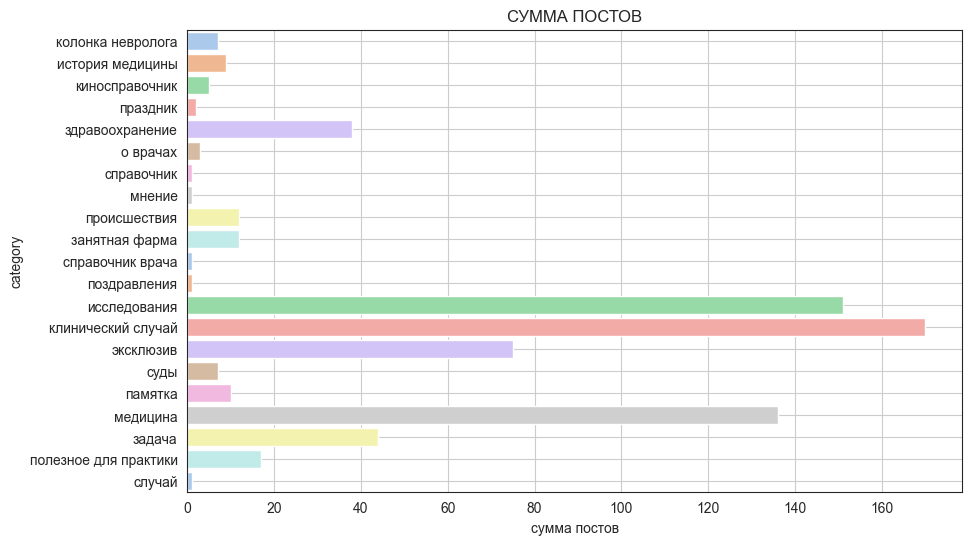

/var/folders/44/ym8sv23940582_szjhc1w17m0000gn/T/ipykernel_12832/4011278276.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=main_metr, y='category', x='общ просмотры', palette='pastel')


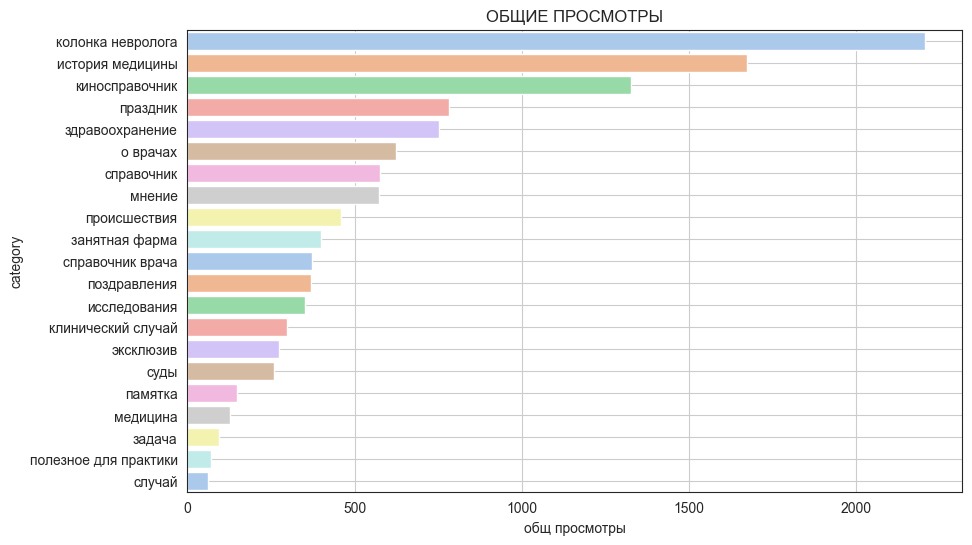

/var/folders/44/ym8sv23940582_szjhc1w17m0000gn/T/ipykernel_12832/4011278276.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=main_metr, y='category', x='общ прочтения', palette='pastel')


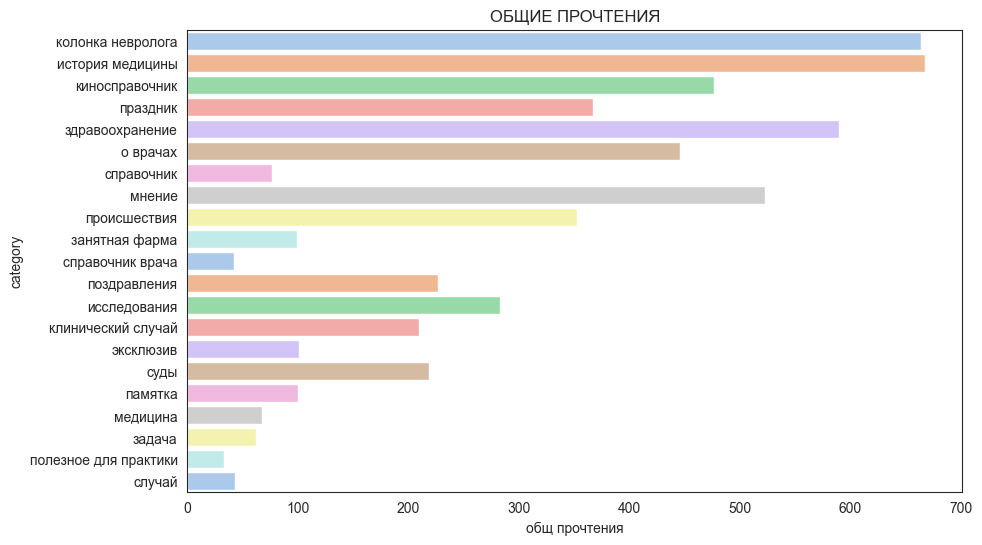

In [157]:
# функция дл сбора основных метрик по медиане
def main_metrics(df):
    # словаь русских метрик
    metrics_ru = {
        'impression_total': 'общ показы',
        'views_total': 'общ просмотры',
        'read_total': 'общ прочтения',
        'share_total': 'общ поделились',
        'transition_total': 'общ переходы',
        'title': 'сумма постов',
        'category': 'категория постов'
    }
    

    # агрегация по категориям постов
    sum_count = df.groupby('category').agg({
        'title': 'count',
        'impression_total': 'median',
        'views_total': 'median',
        'read_total': 'median',
        'share_total': 'median',
        'transition_total': 'median'
    }).sort_values(by='views_total', ascending=False)

    # добавление перевода метрик на русский
    sum_count = sum_count.rename(columns=metrics_ru)

    return sum_count

main_metr = main_metrics(date_df)

print(f'Агрегация по медиане (сортировка по убыванию по общ просмотрам: \n{main_metr}')

# построение столбчатого графика сумм постов по категориям
plt.figure(figsize=(10, 6))
sns.barplot(data=main_metr, y='category', x='сумма постов', palette='pastel')
plt.title('СУММА ПОСТОВ')
plt.grid()
plt.show()
print('=' * 100)
# построение столбчатого графика сумм просмотров по категориям
plt.figure(figsize=(10, 6))
sns.barplot(data=main_metr, y='category', x='общ просмотры', palette='pastel')
plt.title('ОБЩИЕ ПРОСМОТРЫ')
plt.grid()
plt.show()
print('=' * 100)
# построение столбчатого графика сумм прочтений по категориям
plt.figure(figsize=(10, 6))
sns.barplot(data=main_metr, y='category', x='общ прочтения', palette='pastel')
plt.title('ОБЩИЕ ПРОЧТЕНИЯ')
plt.grid
plt.show()

## #5 ВЫВОДЫ ПО БЛОКУ

**основное:**

## №6 МАРКЕТИНГОВЫЕ МЕТРИКИ: CTR, RR, SR, CR (ВОРОНКА)

In [118]:
def mark_metrics_by_category(df):
    # группируем по категории и суммируем нужные столбцы
    grouped = df.groupby(['day_of_week', 'category']).agg(
        sum_impr=('impression_total', 'sum'),
        sum_views=('views_total', 'sum'),
        sum_read=('read_total', 'sum'),
        sum_share=('share_total', 'sum'),
        sum_trans=('transition_total', 'sum')
    )
    
    # считаем производные метрики
    grouped['CTR, %'] = grouped['sum_views'] / grouped['sum_impr'] * 100
    grouped['RR, %'] = grouped['sum_read'] / grouped['sum_views'] * 100
    grouped['SR, %'] = grouped['sum_share'] / grouped['sum_read'] * 100
    grouped['CR, %'] = grouped['sum_trans'] / grouped['sum_read'] * 100
    
    
    return grouped

# получаем таблицу
category_metrics = mark_metrics_by_category(date_df)
print(f'Воронка по маркетинговым метрикам по категориям по дням недели (0-пнд, 6-вскр): \n{category_metrics.round(2)}')

Воронка по маркетинговым метрикам по категориям по дням недели (0-пнд, 6-вскр): 
                                   sum_impr  sum_views  sum_read  sum_share  sum_trans  CTR, %   RR, %   SR, %   CR, %
day_of_week category                                                                                                  
0           задача                  11091.0     1317.0     828.0       23.0       25.0   11.87   62.87    2.78    3.02
            занятная фарма           8785.0      691.0     151.0       12.0        0.0    7.87   21.85    7.95    0.00
            здравоохранение         35352.0    15327.0    7876.0      109.0      206.0   43.36   51.39    1.38    2.62
            исследования           108359.0     9435.0    7223.0      168.0      131.0    8.71   76.56    2.33    1.81
            история медицины          246.0       25.0      11.0       68.0        0.0   10.16   44.00  618.18    0.00
            клинический случай      98380.0     9350.0    6478.0      129.0       51.0

## #5 ВЫВОДЫ ПО БЛОКУ

**основное:**